In [37]:
import pandas as pd
import statistics
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns

# Эксперимент №1
Нулевая гипотеза - тестовая и контрольная выборка равны. Альтернативная - выборки отличаются, средний ARPU тестовой выборки больше этого показателя у контрольной.

In [54]:
df = pd.read_csv('abtests.csv')
exper_1_test = df[(df['experiment_num'] == 1) & (df['experiment_group'] == 'test')]['revenue']
exper_1_control = df[(df['experiment_num'] == 1) & (df['experiment_group'] == 'control')]['revenue']
e1_t_arpu = exper_1_test.mean()
e1_c_arpu = exper_1_control.mean()
e1_t_revenue_median = exper_1_test.median()
e1_c_revenue_median = exper_1_control.median()
print(f'Средний ARPU тестовой группы: {e1_t_arpu:.2f}\nСредний ARPU контрольной группы: {e1_c_arpu:.2f}')
print(f'Медиана выручки в тестовой группе: {e1_t_revenue_median:.2f}\nМедиана выручки в контрольной группе: {e1_c_revenue_median:.2f}')
print(f'Размер тестовой выборки: {exper_1_test.size}\nРазмер контрольной выборки: {exper_1_control.size}')

Средний ARPU тестовой группы: 665.74
Средний ARPU контрольной группы: 722.46
Медиана выручки в тестовой группе: 104.00
Медиана выручки в контрольной группе: 104.00
Размер тестовой выборки: 480
Размер контрольной выборки: 465


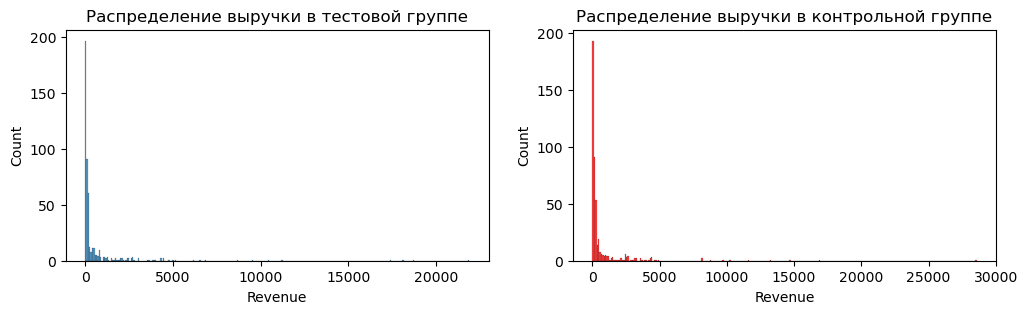

In [44]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.histplot(data=exper_1_test, bins='fd', ax=axes[0])
sns.histplot(data=exper_1_control, bins='fd', color='red', ax=axes[1])
axes[0].set_xlabel('Revenue')
axes[1].set_xlabel('Revenue')
axes[0].set_title('Распределение выручки в тестовой группе')
axes[1].set_title('Распределение выручки в контрольной группе')
plt.show()

На гистограммах видно, что наши распределения не являются нормальными. Оба имеют представляют собой правостороние распределения с пиком на уровне 0 (большинство пользователей не платят ничего, но есть и пользователи, которые платят очень много).
Так как выборки достаточно большие (>400), т-тест Уэлча останется валидным даже при скошенных данных за счет Центральной предельной теоремы. Если наше p-value окажется близко к уровню статистической значимости, нам понадобится дополнительная проверка (тест Манна-Уитни), в обратном же случае нам будет достаточно результатов т-теста Уэлча.

In [28]:
alpha = 0.05
t_statistic, p_value = stats.ttest_ind(exper_1_test, exper_1_control, equal_var=False)
print(f't-статистика: {t_statistic:.2f}')
print(f'p-value: {p_value:.2f}')

t-статистика: -0.40
p-value: 0.69


In [29]:
if p_value > alpha:
    print(f'p-value ({p_value:.2f}) > alpha ({alpha}). Результат статистически не значим. Не отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы равны.')
else:
    print(f'p-value ({p_value:.2f}) <= alpha ({alpha}). Результат статистически значим. Отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы различны.')

p-value (0.69) > alpha (0.05). Результат статистически не значим. Не отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы равны.


P-value первого A/B теста составило 0.69, что намного больше нашего уровня значимости в 5%. Это свидетельствует о том, что результаты эксперимента не являются статистически значимыми и вызваны случайными колебаниями в данных. Кроме того, ARPU контрольной группы оказался даже ниже этого показателя в тестовой группе, что подтверждает, что тест оказался неудачным. Внедрять изменения не рекомендуется.

# Эксперимент №2
Нулевая гипотеза - тестовая и контрольная выборка равны. Альтернативная - выборки отличаются, средний ARPU тестовой выборки больше этого показателя у контрольной.

In [55]:
exper_2_test = df[(df['experiment_num'] == 2) & (df['experiment_group'] == 'test')]['revenue']
exper_2_control = df[(df['experiment_num'] == 2) & (df['experiment_group'] == 'control')]['revenue']
e2_t_arpu = exper_2_test.mean()
e2_c_arpu = exper_2_control.mean()
e2_t_revenue_median = exper_2_test.median()
e2_c_revenue_median = exper_2_control.median()
print(f'Средний ARPU тестовой группы: {e2_t_arpu:.2f}\nСредний ARPU контрольной группы: {e2_c_arpu:.2f}')
print(f'Медиана выручки в тестовой группе: {e2_t_revenue_median:.2f}\nМедиана выручки в контрольной группе: {e2_c_revenue_median:.2f}')
print(f'Размер тестовой выборки: {exper_2_test.size}\nРазмер контрольной выборки: {exper_2_control.size}')

Средний ARPU тестовой группы: 332.93
Средний ARPU контрольной группы: 704.65
Медиана выручки в тестовой группе: 52.00
Медиана выручки в контрольной группе: 74.00
Размер тестовой выборки: 480
Размер контрольной выборки: 465


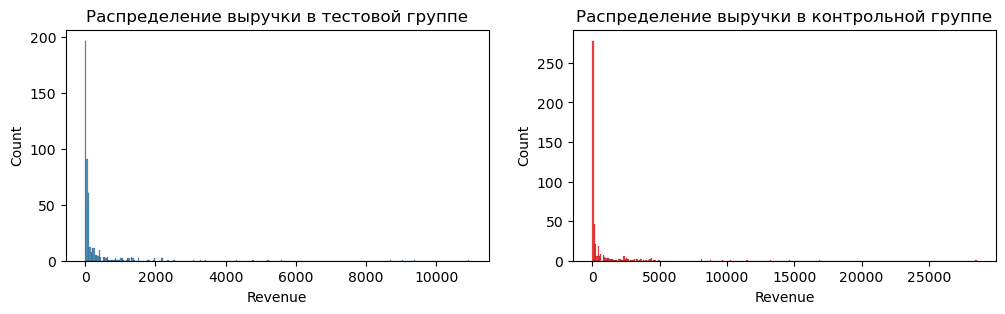

In [57]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.histplot(data=exper_2_test, bins='fd', ax=axes[0])
sns.histplot(data=exper_2_control, bins='fd', color='red', ax=axes[1])
axes[0].set_xlabel('Revenue')
axes[1].set_xlabel('Revenue')
axes[0].set_title('Распределение выручки в тестовой группе')
axes[1].set_title('Распределение выручки в контрольной группе')
plt.show()

In [31]:
alpha = 0.05
t_statistic2, p_value2 = stats.ttest_ind(exper_2_test, exper_2_control, equal_var=False)
print(f't-статистика: {t_statistic2:.2f}')
print(f'p-value: {p_value2:.5f}')

t-статистика: -3.27
p-value: 0.00113


In [32]:
if p_value2 > alpha:
    print(f'p-value ({p_value2:.5f}) > alpha ({alpha}). Результат статистически не значим. Не отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы равны.')
else:
    print(f'p-value ({p_value2:.5f}) <= alpha ({alpha}). Результат статистически значим. Отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы различны.')

p-value (0.00113) <= alpha (0.05). Результат статистически значим. Отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы различны.


P-value второго A/B теста составило 0.00113, это меньше нашего уровня значимости в 5% и свидетельствует о том, что результаты эксперимента являются статистически значимыми. Однако ARPU тестовой группы оказался в 2 раза ниже этого показателя в контрольной группе, т.е. изменения привели к падению выручки. Внедрять изменения не рекомендуется.

# Эксперимент №3
Нулевая гипотеза - тестовая и контрольная выборка равны. Альтернативная - выборки отличаются, средний ARPU тестовой выборки больше этого показателя у контрольной.

In [58]:
exper_3_test = df[(df['experiment_num'] == 3) & (df['experiment_group'] == 'test')]['revenue']
exper_3_control = df[(df['experiment_num'] == 3) & (df['experiment_group'] == 'control')]['revenue']
e3_t_arpu = exper_3_test.mean()
e3_c_arpu = exper_3_control.mean()
e3_t_revenue_median = exper_3_test.median()
e3_c_revenue_median = exper_3_control.median()
print(f'Средний ARPU тестовой группы: {e3_t_arpu:.2f}\nСредний ARPU контрольной группы: {e3_c_arpu:.2f}')
print(f'Медиана выручки в тестовой группе: {e3_t_revenue_median:.2f}\nМедиана выручки в контрольной группе: {e3_c_revenue_median:.2f}')
print(f'Размер тестовой выборки: {exper_3_test.size}\nРазмер контрольной выборки: {exper_3_control.size}')

Средний ARPU тестовой группы: 998.67
Средний ARPU контрольной группы: 663.21
Медиана выручки в тестовой группе: 156.00
Медиана выручки в контрольной группе: 4.00
Размер тестовой выборки: 480
Размер контрольной выборки: 465


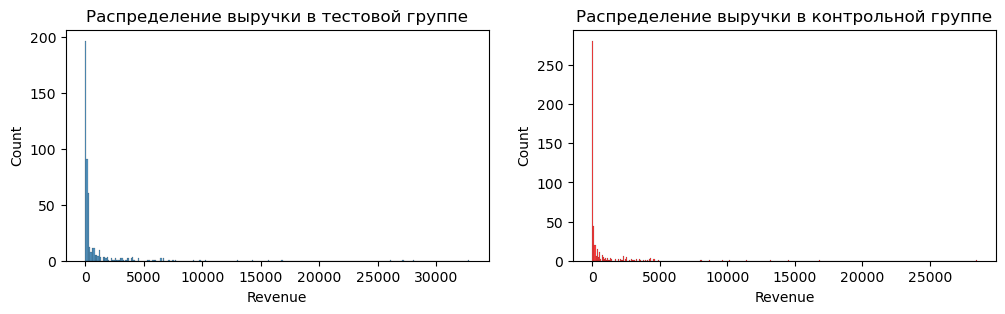

In [59]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.histplot(data=exper_3_test, bins='fd', ax=axes[0])
sns.histplot(data=exper_3_control, bins='fd', color='red', ax=axes[1])
axes[0].set_xlabel('Revenue')
axes[1].set_xlabel('Revenue')
axes[0].set_title('Распределение выручки в тестовой группе')
axes[1].set_title('Распределение выручки в контрольной группе')
plt.show()

In [34]:
alpha = 0.05
t_statistic3, p_value3 = stats.ttest_ind(exper_3_test, exper_3_control, equal_var=False)
print(f't-статистика: {t_statistic3:.2f}')
print(f'p-value: {p_value3:.2f}')

t-статистика: 1.88
p-value: 0.06


In [35]:
if p_value3 > alpha:
    print(f'p-value ({p_value3:.2f}) > alpha ({alpha}). Результат статистически не значим. Не отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы равны.')
else:
    print(f'p-value ({p_value3:.2f}) <= alpha ({alpha}). Результат статистически значим. Отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы различны.')

p-value (0.06) > alpha (0.05). Результат статистически не значим. Не отклоняем нулевую гипотезу. ARPU тестовой и контрольной группы равны.


В тестовой группе 3 эксперимента наблюдается сильный положительный тренд по сравнению с контрольной группой: 998.67 против 663.21, это рост на 50,6%. Однако полученный p-value немного выше нашего порога статистической значимости (0.06). Это значит, что нам следует воспользоваться дополнительной проверкой и провести тест Манна-Уитни.

In [61]:
from scipy.stats import mannwhitneyu
u_statistic, p_value_u = mannwhitneyu(exper_3_test, exper_3_control, alternative='two-sided')
print(f'U-statistic: {u_statistic}')
print(f'P-value: {p_value_u:.5f}')

U-statistic: 124911.0
P-value: 0.00100


P-value в рамках теста Манна-Уитни составило 0.00100, что меньше порога статистической значимости и свидетельствует о статистической значимости теста. С учетом наличия положительной тенденции рекомендуется внедрять результаты теста.